In [1]:
import pandas as pd

df = pd.read_parquet('../../data/processed/dataset.parquet')
df.head()

,pickup_hour,zone,demand,hour,day,month,lag_1,lag_24,global_lag_24,lag_24_norm,global_lag_24_norm,diff
0,2016-01-02 00:00:00,0,22,0,5,1,34.0,15.0,754.0,0.107692,0.823851,-739.0
1,2016-01-02 01:00:00,0,18,1,5,1,22.0,22.0,844.0,0.161538,0.922319,-822.0
2,2016-01-02 02:00:00,0,15,2,5,1,18.0,13.0,729.0,0.092308,0.796499,-716.0
3,2016-01-02 03:00:00,0,14,3,5,1,15.0,20.0,691.0,0.146154,0.754923,-671.0
4,2016-01-02 04:00:00,0,13,4,5,1,14.0,14.0,436.0,0.100000,0.475930,-422.0


In [2]:
df = df.sort_values('pickup_hour')

In [3]:
df.drop(columns=['pickup_hour'], inplace=True)

In [4]:
df.head()

,zone,demand,hour,day,month,lag_1,lag_24,global_lag_24,lag_24_norm,global_lag_24_norm,diff
0,0,22,0,5,1,34.0,15.0,754.0,0.107692,0.823851,-739.0
102244,29,17,0,5,1,10.0,30.0,754.0,0.223077,0.823851,-724.0
97919,28,20,0,5,1,29.0,28.0,754.0,0.207692,0.823851,-726.0
93894,27,5,0,5,1,4.0,13.0,754.0,0.092308,0.823851,-741.0
88185,25,50,0,5,1,54.0,49.0,754.0,0.369231,0.823851,-705.0


In [5]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['demand'])
y = df['demand']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
import mlflow

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\pydantic\_internal\_fields.py:149: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
!pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [10]:
import numpy as np

In [11]:
models = {
    "Linear": LinearRegression(fit_intercept=False),
    "RF": RandomForestRegressor(n_estimators=300, max_depth=10),
    "XGB": xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.01),
}

results = []

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        
        # Train model
        model.fit(X_train, y_train)

        # Predict test set
        preds = model.predict(X_test)

        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)


        mlflow.log_param("model", name)

        # Log metrics
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)

        # Save model
        mlflow.sklearn.log_model(model, artifact_path="model")

        # Store result
        results.append({
            "model": name,
            "rmse": rmse,
            "mae": mae,
            "r2": r2
        })

        print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

2026/05/20 02:22:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 02:22:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear -> RMSE: 7.20, MAE: 5.05, R2: 0.83


2026/05/20 02:23:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 02:23:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF -> RMSE: 5.99, MAE: 4.16, R2: 0.88


2026/05/20 02:24:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 02:24:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB -> RMSE: 6.15, MAE: 4.39, R2: 0.88


In [12]:
results_df = pd.DataFrame(results)
results_df.sort_values("rmse", ascending=True, inplace=True)
results_df

,model,rmse,mae,r2
1,RF,5.988577,4.159086,0.882356
2,XGB,6.147111,4.391001,0.876045
0,Linear,7.200853,5.049281,0.829905


In [13]:
df.shape

(106542, 11)

In [14]:
!mlflow ui

^C


In [ ]:
model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1)

# Train model
model.fit(X_train, y_train)

# Predict test set
preds = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"XGB -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

XGB -> RMSE: 5.48, MAE: 3.85, R2: 0.90


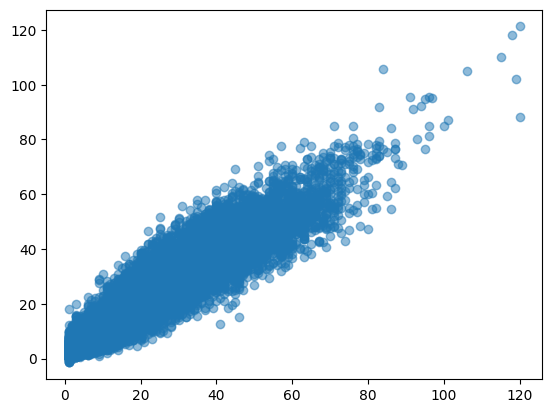

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, preds, alpha=0.5)

In [ ]:
import joblib
joblib.dump(model, '../../models/taxi_demand.joblib')

['../../models/taxi_demand.joblib']